<a href="https://colab.research.google.com/github/Pete-Reseacher/python-geoscience/blob/main/Copy_of_Spatial_Analysis_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# !pip install geopandas
import geopandas as gpd

In [ ]:
# Working with shapefile lines

df = gpd.read_file("shp/Guayaqui_Lineas.shp")

In [ ]:
df.head()

,osm_id,name,highway,waterway,aerialway,barrier,man_made,z_order,other_tags,SPEED2,geometry
0,1,Francisco De Orellana,trunk,None,None,None,None,8,"""alt_name""=>""Eje"",""lanes""=>""3"",""maxspeed""=>""70...",60,"LINESTRING (-79.90486 -2.14027, -79.9047 -2.14..."
1,1,Francisco De Orellana,trunk,None,None,None,None,28,"""alt_name""=>""Eje"",""bridge""=>""yes"",""lanes""=>""3""...",60,"LINESTRING (-79.90706 -2.13718, -79.90687 -2.1..."
2,0,Francisco De Orellana,trunk,None,None,None,None,8,"""alt_name""=>""Eje"",""lanes""=>""3"",""oneway""=>""yes""...",120,"LINESTRING (-79.90691 -2.13709, -79.90725 -2.1..."
3,1,Francisco De Orellana,trunk,None,None,None,None,28,"""alt_name""=>""Eje"",""bridge""=>""yes"",""lanes""=>""3""...",60,"LINESTRING (-79.90471 -2.14018, -79.90591 -2.1..."
4,1,Rodolfo Baquerizo Nazur,primary,None,None,None,None,7,"""alt_name""=>""Calle 19 NE"",""lanes""=>""2"",""oneway...",60,"LINESTRING (-79.90762 -2.13258, -79.90754 -2.1..."


In [ ]:
df.columns

Index(['osm_id', 'name', 'highway', 'waterway', 'aerialway', 'barrier',
       'man_made', 'z_order', 'other_tags', 'SPEED2', 'geometry'],
      dtype='object')

In [ ]:
df["highway"].value_counts()

highway
residential       1163
footway            625
living_street       90
tertiary            88
secondary           84
primary             50
service             34
primary_link        23
trunk_link          23
trunk               19
secondary_link      17
steps                8
tertiary_link        4
cycleway             2
unclassified         1
track                1
Name: count, dtype: int64

<Axes: >

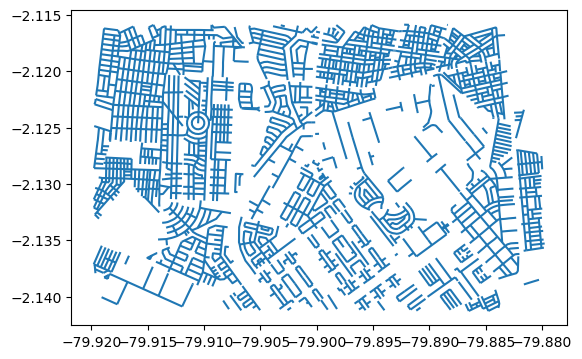

In [ ]:
df[df["highway"]=="residential"].plot()

<Axes: >

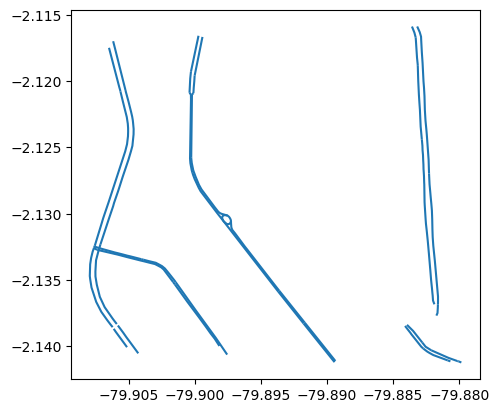

In [ ]:
df[df["highway"]=="primary"].plot()

<Axes: >

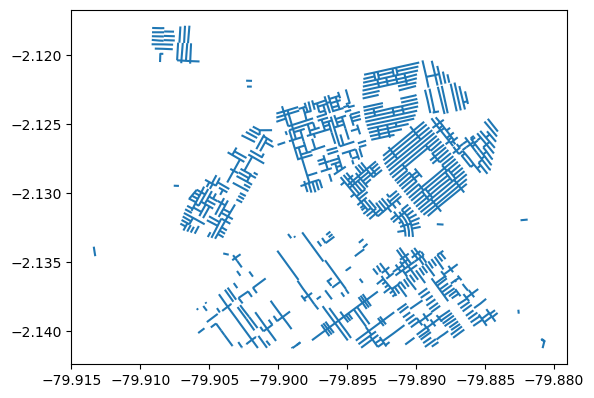

In [ ]:
df[df["highway"]=="footway"].plot()

In [ ]:
df.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
df2 = gpd.read_file("shp/Guayaqui_Poligonos.shp")

In [ ]:
df2.head()

,osm_id,osm_way_id,name,type,aeroway,amenity,admin_leve,barrier,boundary,building,...,military,natural,office,place,shop,sport,tourism,other_tags,Area,geometry
0,2048284,None,Los Ãlamos,boundary,None,None,10,None,administrative,None,...,None,None,None,None,None,None,None,"""is_in:county""=>""Guayaquil"",""wikidata""=>""Q5547...",411645.776,"POLYGON ((-79.90771 -2.13387, -79.9083 -2.1337..."
1,6415358,None,Centro Comercial Polaris,multipolygon,None,None,None,None,None,commercial,...,None,None,None,None,None,None,None,"""addr:street""=>""Isidro Ayora Cueva""",3600.819,"MULTIPOLYGON (((-79.90054 -2.11775, -79.90041 ..."
2,None,35692043,Parque de la 4ta,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,3827.957,"POLYGON ((-79.89476 -2.13811, -79.89455 -2.138..."
3,None,35692054,Albocentro I,None,None,None,None,None,None,retail,...,None,None,None,None,None,None,None,None,1010.729,"POLYGON ((-79.89677 -2.14088, -79.89669 -2.141..."
4,None,35692055,Albocentro II,None,None,None,None,None,None,retail,...,None,None,None,None,None,None,None,None,1470.616,"POLYGON ((-79.89786 -2.14006, -79.89763 -2.139..."


In [ ]:
df.columns

Index(['osm_id', 'name', 'highway', 'waterway', 'aerialway', 'barrier',
       'man_made', 'z_order', 'other_tags', 'SPEED2', 'geometry'],
      dtype='object')

<Axes: >

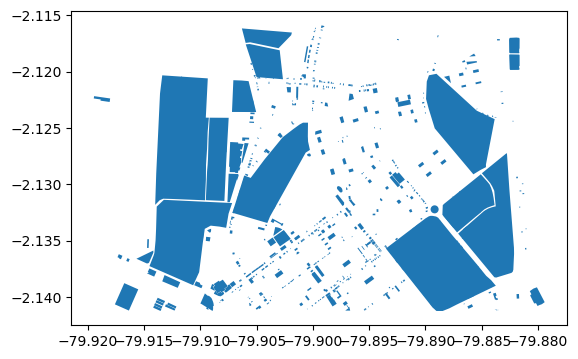

In [ ]:
df2.plot()

In [ ]:
#Working with subsurface data

wells = pd.read_csv("wells_master.csv")

In [ ]:
wells.head()

,Well_ID,Well_Name,X_UTM_m,Y_UTM_m,CRS_EPSG,Field,Block,Quadrant,Trajectory,Status,...,Oil_Saturation_frac,Gas_Saturation_frac,Total_Depth_MD_m,Total_Depth_TVDSS_m,Deviation_Azimuth_deg,Max_Inclination_deg,Lateral_Length_m,Distance_to_Nearest_Fault_m,Nearest_Fault_ID,Reservoir_Quality_Index
0,KW-0001,Kimbala-0001,499487.37,782754.65,32632,Kimbala,B02-02,SW,Vertical,Producer,...,0.287,0.075,3226.2,3152.0,NaN,5.4,0.0,3252.6,F03,37.2
1,KW-0002,Kimbala-0002,519217.08,777630.58,32632,Kimbala,B02-05,SE,Deviated,DryHole,...,0.278,0.051,3374.2,3374.2,221.4,36.9,429.6,190.2,F06,40.7
2,KW-0003,Kimbala-0003,521265.78,789047.99,32632,Kimbala,B03-06,NE,Vertical,Appraisal,...,0.382,0.057,3251.2,3224.9,NaN,0.4,0.0,668.6,F06,42.6
3,KW-0004,Kimbala-0004,523734.25,793852.73,32632,Kimbala,B04-06,NE,Horizontal,DryHole,...,0.352,0.028,4655.7,3051.6,108.4,84.5,2238.6,817.1,F06,39.2
4,KW-0005,Kimbala-0005,510791.07,793959.06,32632,Kimbala,B04-04,NE,Vertical,Producer,...,0.438,0.075,2905.5,2905.5,NaN,2.5,0.0,717.7,F04,37.7


In [ ]:
print("Number of wells:", len(wells))

Number of wells: 2500


In [ ]:
wells.describe()

,X_UTM_m,Y_UTM_m,CRS_EPSG,KB_Elevation_m,Water_Depth_m,Top_Reservoir_TVDSS_m,Gross_Thickness_m,Net_to_Gross_frac,NetPay_m,Porosity_frac,...,Water_Saturation_frac,Oil_Saturation_frac,Gas_Saturation_frac,Total_Depth_MD_m,Total_Depth_TVDSS_m,Deviation_Azimuth_deg,Max_Inclination_deg,Lateral_Length_m,Distance_to_Nearest_Fault_m,Reservoir_Quality_Index
count,2500.000000,2500.000000,2500.0,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,...,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,1241.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,509891.378016,784869.935332,32632.0,144.766640,34.791920,2627.377120,54.52072,0.430284,21.372280,0.134537,...,0.589733,0.359465,0.051361,3422.708920,3172.035880,180.668332,30.034680,633.104400,2090.639440,39.605320
std,8947.564757,6936.132926,0.0,11.875096,17.450267,132.971773,14.96162,0.089089,8.592622,0.024442,...,0.089820,0.094536,0.028494,611.483222,205.823055,103.388018,32.437726,832.552628,1626.783429,7.943445
min,490274.690000,771297.330000,32632.0,103.700000,0.000000,2413.400000,18.00000,0.120000,2.500000,0.067000,...,0.292000,0.023000,0.000000,2583.300000,2583.300000,0.300000,-3.600000,0.000000,2.800000,22.500000
25%,503250.745000,779131.352500,32632.0,137.000000,22.600000,2520.600000,44.10000,0.368000,15.200000,0.118000,...,0.529000,0.295000,0.030000,3042.475000,3021.400000,91.800000,2.900000,0.000000,807.125000,34.100000
50%,510284.530000,785204.840000,32632.0,144.600000,34.600000,2579.250000,53.30000,0.430000,20.100000,0.133000,...,0.593000,0.357000,0.051000,3182.800000,3144.450000,179.500000,8.350000,0.000000,1747.200000,38.100000
75%,516901.425000,790264.255000,32632.0,152.700000,46.700000,2716.775000,64.10000,0.489000,25.800000,0.149000,...,0.651000,0.424000,0.072000,3444.650000,3303.925000,265.900000,50.025000,1011.750000,2842.600000,43.800000
max,528541.740000,799329.330000,32632.0,184.600000,90.500000,2983.400000,113.20000,0.761000,72.200000,0.236000,...,0.916000,0.679000,0.146000,5458.700000,3909.300000,358.700000,91.800000,3197.400000,7190.700000,70.800000


In [ ]:
wells.columns

Index(['Well_ID', 'Well_Name', 'X_UTM_m', 'Y_UTM_m', 'CRS_EPSG', 'Field',
       'Block', 'Quadrant', 'Trajectory', 'Status', 'Completion_Type',
       'Spud_Date', 'Completion_Date', 'KB_Elevation_m', 'Water_Depth_m',
       'Top_Reservoir_TVDSS_m', 'Gross_Thickness_m', 'Net_to_Gross_frac',
       'NetPay_m', 'Porosity_frac', 'Permeability_mD', 'Water_Saturation_frac',
       'Oil_Saturation_frac', 'Gas_Saturation_frac', 'Total_Depth_MD_m',
       'Total_Depth_TVDSS_m', 'Deviation_Azimuth_deg', 'Max_Inclination_deg',
       'Lateral_Length_m', 'Distance_to_Nearest_Fault_m', 'Nearest_Fault_ID',
       'Reservoir_Quality_Index'],
      dtype='object')

In [ ]:
gdf_wells = gpd.GeoDataFrame(wells, geometry=gpd.points_from_xy(wells.X_UTM_m, wells.Y_UTM_m),
                             crs="EPSG:32632")

In [ ]:
gdf_wells.head()

,Well_ID,Well_Name,X_UTM_m,Y_UTM_m,CRS_EPSG,Field,Block,Quadrant,Trajectory,Status,...,Gas_Saturation_frac,Total_Depth_MD_m,Total_Depth_TVDSS_m,Deviation_Azimuth_deg,Max_Inclination_deg,Lateral_Length_m,Distance_to_Nearest_Fault_m,Nearest_Fault_ID,Reservoir_Quality_Index,geometry
0,KW-0001,Kimbala-0001,499487.37,782754.65,32632,Kimbala,B02-02,SW,Vertical,Producer,...,0.075,3226.2,3152.0,NaN,5.4,0.0,3252.6,F03,37.2,POINT (499487.37 782754.65)
1,KW-0002,Kimbala-0002,519217.08,777630.58,32632,Kimbala,B02-05,SE,Deviated,DryHole,...,0.051,3374.2,3374.2,221.4,36.9,429.6,190.2,F06,40.7,POINT (519217.08 777630.58)
2,KW-0003,Kimbala-0003,521265.78,789047.99,32632,Kimbala,B03-06,NE,Vertical,Appraisal,...,0.057,3251.2,3224.9,NaN,0.4,0.0,668.6,F06,42.6,POINT (521265.78 789047.99)
3,KW-0004,Kimbala-0004,523734.25,793852.73,32632,Kimbala,B04-06,NE,Horizontal,DryHole,...,0.028,4655.7,3051.6,108.4,84.5,2238.6,817.1,F06,39.2,POINT (523734.25 793852.73)
4,KW-0005,Kimbala-0005,510791.07,793959.06,32632,Kimbala,B04-04,NE,Vertical,Producer,...,0.075,2905.5,2905.5,NaN,2.5,0.0,717.7,F04,37.7,POINT (510791.07 793959.06)


In [ ]:
gdf_wells.columns

Index(['Well_ID', 'Well_Name', 'X_UTM_m', 'Y_UTM_m', 'CRS_EPSG', 'Field',
       'Block', 'Quadrant', 'Trajectory', 'Status', 'Completion_Type',
       'Spud_Date', 'Completion_Date', 'KB_Elevation_m', 'Water_Depth_m',
       'Top_Reservoir_TVDSS_m', 'Gross_Thickness_m', 'Net_to_Gross_frac',
       'NetPay_m', 'Porosity_frac', 'Permeability_mD', 'Water_Saturation_frac',
       'Oil_Saturation_frac', 'Gas_Saturation_frac', 'Total_Depth_MD_m',
       'Total_Depth_TVDSS_m', 'Deviation_Azimuth_deg', 'Max_Inclination_deg',
       'Lateral_Length_m', 'Distance_to_Nearest_Fault_m', 'Nearest_Fault_ID',
       'Reservoir_Quality_Index', 'geometry'],
      dtype='object')

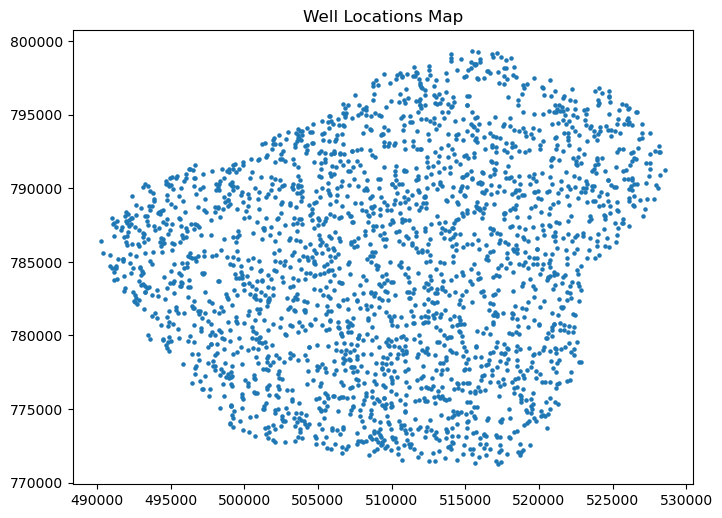

In [ ]:
gdf_wells.plot(figsize=(8, 8), markersize=5)
plt.title("Well Locations Map")
plt.show()

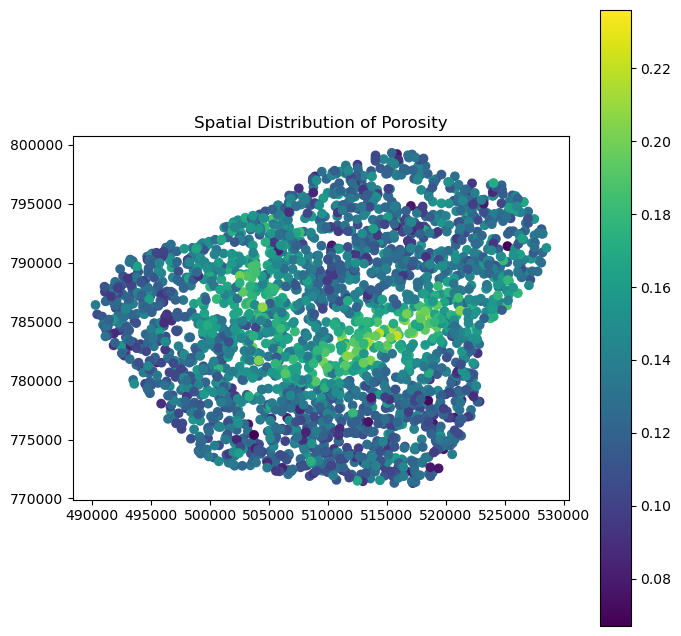

In [ ]:
#Spatially view porosity Spread across wells
gdf_wells.plot(column="Porosity_frac", cmap="viridis", legend=True, figsize=(8,8))
plt.title("Spatial Distribution of Porosity")
plt.show()

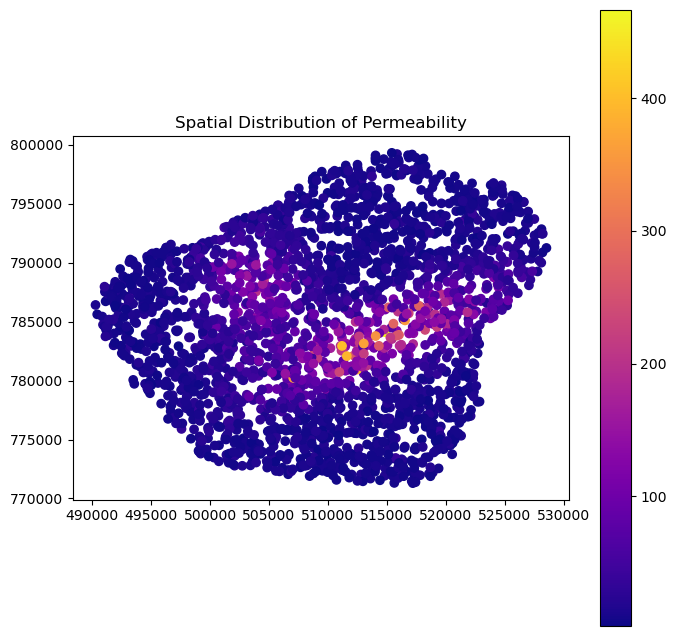

In [ ]:
#Spatially view permeability Spread across wells
gdf_wells.plot(column="Permeability_mD", cmap="plasma", legend=True, figsize=(8,8))
plt.title("Spatial Distribution of Permeability")
plt.show()

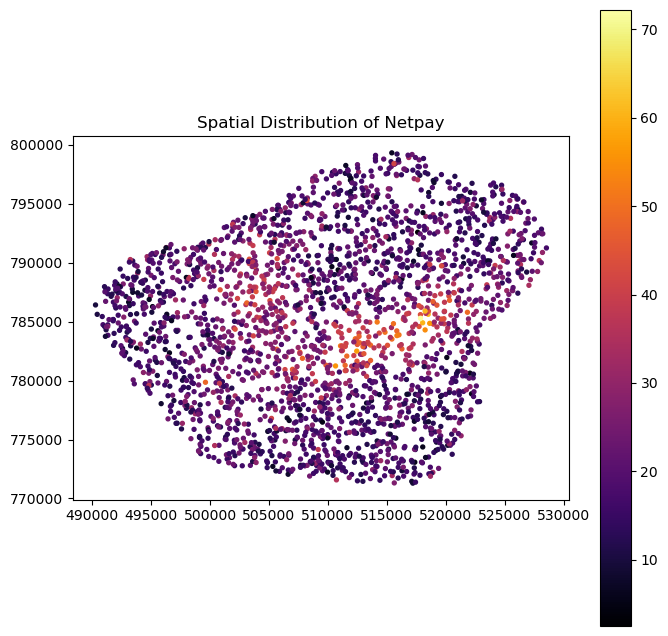

In [ ]:
#Spatially view permeability Spread across wells
gdf_wells.plot(column="NetPay_m", cmap="inferno", legend=True, markersize=8, figsize=(8,8))
plt.title("Spatial Distribution of Netpay")
plt.show()

In [ ]:
zones = pd.read_csv("reservoir_zones.csv")

In [ ]:
zones.head()

,Well_ID,Well_Name,Zone_Order,Formation,Lithology_Class,Top_TVDSS_m,Base_TVDSS_m,Gross_Thickness_m,Net_to_Gross_frac,Porosity_frac,Permeability_mD,Water_Saturation_frac,Vshale_frac
0,KW-0001,Kimbala-0001,1,Shale_A,Shale,2529.1,2557.5,28.4,0.096,0.074,0.6,0.915,0.759
1,KW-0001,Kimbala-0001,2,Sand_A,ReservoirSand,2557.5,2582.4,25.0,0.294,0.145,13.4,0.772,0.251
2,KW-0001,Kimbala-0001,3,Shale_B,Shale,2582.4,2615.6,33.1,0.127,0.077,0.5,0.937,0.733
3,KW-0001,Kimbala-0001,4,Sand_B,ReservoirSand,2615.6,2654.5,39.0,0.382,0.128,13.1,0.485,0.311
4,KW-0001,Kimbala-0001,5,Shale_C,Shale,2654.5,2697.4,42.8,0.059,0.050,0.6,0.947,0.784


In [ ]:
zones["NetPay_m"] = zones["Gross_Thickness_m"] * zones["Net_to_Gross_frac"]


In [ ]:
zones.columns

Index(['Well_ID', 'Well_Name', 'Zone_Order', 'Formation', 'Lithology_Class',
       'Top_TVDSS_m', 'Base_TVDSS_m', 'Gross_Thickness_m', 'Net_to_Gross_frac',
       'Porosity_frac', 'Permeability_mD', 'Water_Saturation_frac',
       'Vshale_frac', 'NetPay_m'],
      dtype='object')

In [ ]:
zone_avg = zones.groupby("Well_Name")[["Porosity_frac", "Permeability_mD", "NetPay_m"
                                      ]].mean().reset_index()


In [ ]:
zone_avg.head()

,Well_Name,Porosity_frac,Permeability_mD,NetPay_m
0,Kimbala-0001,0.107125,6.325,8.713300
1,Kimbala-0002,0.098375,33.825,11.940200
2,Kimbala-0003,0.091875,23.125,20.977612
3,Kimbala-0004,0.089875,4.050,21.116687
4,Kimbala-0005,0.107000,11.500,6.912363


In [ ]:
merged = wells.merge(zone_avg, on="Well_Name", how="left")

In [ ]:
merged.head()

,Well_ID,Well_Name,X_UTM_m,Y_UTM_m,CRS_EPSG,Field,Block,Quadrant,Trajectory,Status,...,Total_Depth_TVDSS_m,Deviation_Azimuth_deg,Max_Inclination_deg,Lateral_Length_m,Distance_to_Nearest_Fault_m,Nearest_Fault_ID,Reservoir_Quality_Index,Porosity_frac_y,Permeability_mD_y,NetPay_m_y
0,KW-0001,Kimbala-0001,499487.37,782754.65,32632,Kimbala,B02-02,SW,Vertical,Producer,...,3152.0,NaN,5.4,0.0,3252.6,F03,37.2,0.107125,6.325,8.713300
1,KW-0002,Kimbala-0002,519217.08,777630.58,32632,Kimbala,B02-05,SE,Deviated,DryHole,...,3374.2,221.4,36.9,429.6,190.2,F06,40.7,0.098375,33.825,11.940200
2,KW-0003,Kimbala-0003,521265.78,789047.99,32632,Kimbala,B03-06,NE,Vertical,Appraisal,...,3224.9,NaN,0.4,0.0,668.6,F06,42.6,0.091875,23.125,20.977612
3,KW-0004,Kimbala-0004,523734.25,793852.73,32632,Kimbala,B04-06,NE,Horizontal,DryHole,...,3051.6,108.4,84.5,2238.6,817.1,F06,39.2,0.089875,4.050,21.116687
4,KW-0005,Kimbala-0005,510791.07,793959.06,32632,Kimbala,B04-04,NE,Vertical,Producer,...,2905.5,NaN,2.5,0.0,717.7,F04,37.7,0.107000,11.500,6.912363


In [ ]:
merged.columns

Index(['Well_ID', 'Well_Name', 'X_UTM_m', 'Y_UTM_m', 'CRS_EPSG', 'Field',
       'Block', 'Quadrant', 'Trajectory', 'Status', 'Completion_Type',
       'Spud_Date', 'Completion_Date', 'KB_Elevation_m', 'Water_Depth_m',
       'Top_Reservoir_TVDSS_m', 'Gross_Thickness_m', 'Net_to_Gross_frac',
       'NetPay_m_x', 'Porosity_frac_x', 'Permeability_mD_x',
       'Water_Saturation_frac', 'Oil_Saturation_frac', 'Gas_Saturation_frac',
       'Total_Depth_MD_m', 'Total_Depth_TVDSS_m', 'Deviation_Azimuth_deg',
       'Max_Inclination_deg', 'Lateral_Length_m',
       'Distance_to_Nearest_Fault_m', 'Nearest_Fault_ID',
       'Reservoir_Quality_Index', 'Porosity_frac_y', 'Permeability_mD_y',
       'NetPay_m_y'],
      dtype='object')

In [ ]:
field = gpd.read_file("field_boundary.geojson")
faults = gpd.read_file("faults.geojson")

In [ ]:
faults.head()

,Fault_ID,Throw_Class,geometry
0,F01,minor,"LINESTRING (491369.78 780493.527, 494675.835 7..."
1,F02,moderate,"LINESTRING (491522.493 779335.207, 492473.413 ..."
2,F03,moderate,"LINESTRING (496186.872 774389.972, 496292.017 ..."
3,F04,minor,"LINESTRING (504966.045 770041.155, 510531.319 ..."
4,F05,minor,"LINESTRING (511000.218 769404.813, 513332.153 ..."


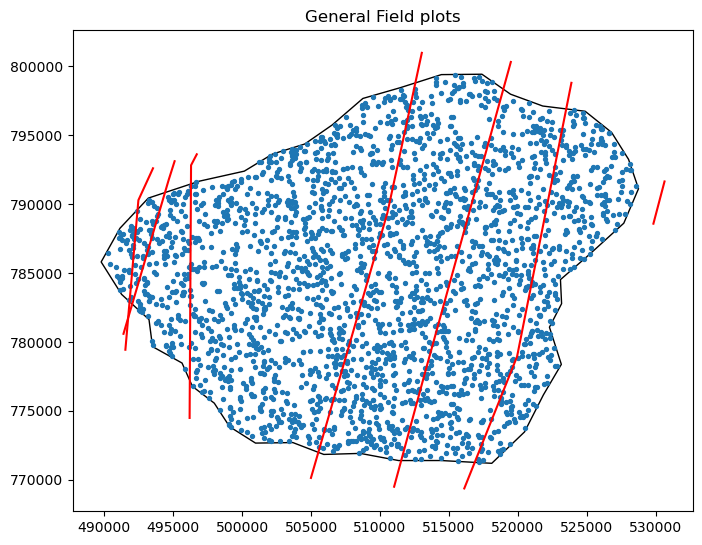

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))

field.plot(ax=ax, color="none", edgecolor="black")
faults.plot(ax=ax, color="red")
gdf_wells.plot(ax=ax, markersize=8)

plt.title("General Field plots")
plt.show()

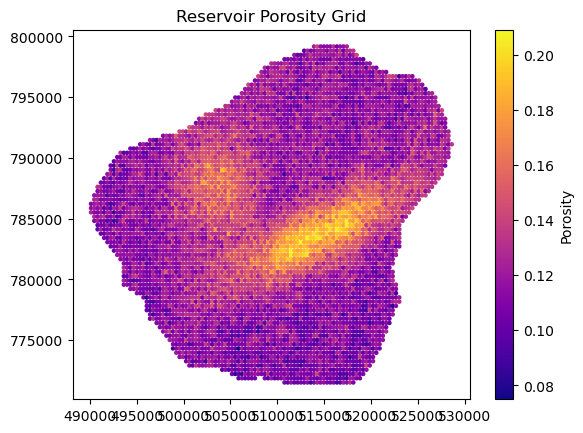

In [ ]:
# Visualize Reservoir Grid

grid = pd.read_csv("reservoir_grid.csv")

plt.scatter(grid.X_UTM_m, grid.Y_UTM_m, c=grid.Porosity_frac, cmap="plasma",
            s=5)
plt.colorbar(label="Porosity")
plt.title("Reservoir Porosity Grid")
plt.show()

#Well spacing analysis
#Distance to faults analysis
#Spatial Interpolation
#Sweet spot detection

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial import cKDTree
from scipy.interpolate import griddata
from shapely.geometry import Point
from matplotlib.colors import Normalize

# !pip install scipy

In [ ]:
wells.head()

,Well_ID,Well_Name,X_UTM_m,Y_UTM_m,CRS_EPSG,Field,Block,Quadrant,Trajectory,Status,...,Oil_Saturation_frac,Gas_Saturation_frac,Total_Depth_MD_m,Total_Depth_TVDSS_m,Deviation_Azimuth_deg,Max_Inclination_deg,Lateral_Length_m,Distance_to_Nearest_Fault_m,Nearest_Fault_ID,Reservoir_Quality_Index
0,KW-0001,Kimbala-0001,499487.37,782754.65,32632,Kimbala,B02-02,SW,Vertical,Producer,...,0.287,0.075,3226.2,3152.0,NaN,5.4,0.0,3252.6,F03,37.2
1,KW-0002,Kimbala-0002,519217.08,777630.58,32632,Kimbala,B02-05,SE,Deviated,DryHole,...,0.278,0.051,3374.2,3374.2,221.4,36.9,429.6,190.2,F06,40.7
2,KW-0003,Kimbala-0003,521265.78,789047.99,32632,Kimbala,B03-06,NE,Vertical,Appraisal,...,0.382,0.057,3251.2,3224.9,NaN,0.4,0.0,668.6,F06,42.6
3,KW-0004,Kimbala-0004,523734.25,793852.73,32632,Kimbala,B04-06,NE,Horizontal,DryHole,...,0.352,0.028,4655.7,3051.6,108.4,84.5,2238.6,817.1,F06,39.2
4,KW-0005,Kimbala-0005,510791.07,793959.06,32632,Kimbala,B04-04,NE,Vertical,Producer,...,0.438,0.075,2905.5,2905.5,NaN,2.5,0.0,717.7,F04,37.7


In [ ]:
wells_paths = gpd.read_file("well_paths.geojson")
wells_paths.head()

,Well_ID,Well_Name,Trajectory,Status,geometry
0,KW-0001,Kimbala-0001,Vertical,Producer,"LINESTRING (499487.37 782754.65, 499487.37 782..."
1,KW-0002,Kimbala-0002,Deviated,DryHole,"LINESTRING (519217.08 777630.58, 519075.03 777..."
2,KW-0003,Kimbala-0003,Vertical,Appraisal,"LINESTRING (521265.78 789047.99, 521265.78 789..."
3,KW-0004,Kimbala-0004,Horizontal,DryHole,"LINESTRING (523734.25 793852.73, 524261.462 79..."
4,KW-0005,Kimbala-0005,Vertical,Producer,"LINESTRING (510791.07 793959.06, 510791.07 793..."


In [ ]:
wells.columns

Index(['Well_ID', 'Well_Name', 'X_UTM_m', 'Y_UTM_m', 'CRS_EPSG', 'Field',
       'Block', 'Quadrant', 'Trajectory', 'Status', 'Completion_Type',
       'Spud_Date', 'Completion_Date', 'KB_Elevation_m', 'Water_Depth_m',
       'Top_Reservoir_TVDSS_m', 'Gross_Thickness_m', 'Net_to_Gross_frac',
       'NetPay_m', 'Porosity_frac', 'Permeability_mD', 'Water_Saturation_frac',
       'Oil_Saturation_frac', 'Gas_Saturation_frac', 'Total_Depth_MD_m',
       'Total_Depth_TVDSS_m', 'Deviation_Azimuth_deg', 'Max_Inclination_deg',
       'Lateral_Length_m', 'Distance_to_Nearest_Fault_m', 'Nearest_Fault_ID',
       'Reservoir_Quality_Index'],
      dtype='object')

In [ ]:
gdf_wells.head()

,Well_ID,Well_Name,X_UTM_m,Y_UTM_m,CRS_EPSG,Field,Block,Quadrant,Trajectory,Status,...,Gas_Saturation_frac,Total_Depth_MD_m,Total_Depth_TVDSS_m,Deviation_Azimuth_deg,Max_Inclination_deg,Lateral_Length_m,Distance_to_Nearest_Fault_m,Nearest_Fault_ID,Reservoir_Quality_Index,geometry
0,KW-0001,Kimbala-0001,499487.37,782754.65,32632,Kimbala,B02-02,SW,Vertical,Producer,...,0.075,3226.2,3152.0,NaN,5.4,0.0,3252.6,F03,37.2,POINT (499487.37 782754.65)
1,KW-0002,Kimbala-0002,519217.08,777630.58,32632,Kimbala,B02-05,SE,Deviated,DryHole,...,0.051,3374.2,3374.2,221.4,36.9,429.6,190.2,F06,40.7,POINT (519217.08 777630.58)
2,KW-0003,Kimbala-0003,521265.78,789047.99,32632,Kimbala,B03-06,NE,Vertical,Appraisal,...,0.057,3251.2,3224.9,NaN,0.4,0.0,668.6,F06,42.6,POINT (521265.78 789047.99)
3,KW-0004,Kimbala-0004,523734.25,793852.73,32632,Kimbala,B04-06,NE,Horizontal,DryHole,...,0.028,4655.7,3051.6,108.4,84.5,2238.6,817.1,F06,39.2,POINT (523734.25 793852.73)
4,KW-0005,Kimbala-0005,510791.07,793959.06,32632,Kimbala,B04-04,NE,Vertical,Producer,...,0.075,2905.5,2905.5,NaN,2.5,0.0,717.7,F04,37.7,POINT (510791.07 793959.06)


In [ ]:
gdf_grid = gpd.GeoDataFrame(grid.copy(), geometry=gpd.points_from_xy(
    grid["X_UTM_m"], grid["Y_UTM_m"], crs="EPSG:32632"))

In [ ]:
#if you are using data from another source, make sure to set the crs system to use the same origins

field = field.to_crs("EPSG:32632")
faults = faults.to_crs("EPSG:32632")
wells_paths = wells_paths.to_crs("EPSG:32632")

#Well Spacing analysis

- Are wells tightly clustered or widely separated?
- Are our locations Oversampled or Undersampled?
- Where can we still drill (Infill drilling)?


In [ ]:
coords = wells[["X_UTM_m", "Y_UTM_m"]].to_numpy()

tree = cKDTree(coords)

distances, indices = tree.query(coords, k=2)

In [ ]:
wells["Nearest_Well_Distance"] = distances[:, 1]
wells["Nearest_Well_Index"] = indices[:, 1]
wells["Nearest_Well_Name"] = wells.iloc[wells["Nearest_Well_Index"]]["Well_Name"].values

wells[["Well_Name", "Nearest_Well_Name", "Nearest_Well_Distance"]].head()

,Well_Name,Nearest_Well_Name,Nearest_Well_Distance
0,Kimbala-0001,Kimbala-1839,357.182259
1,Kimbala-0002,Kimbala-0015,343.726017
2,Kimbala-0003,Kimbala-0155,373.279525
3,Kimbala-0004,Kimbala-1175,314.098677
4,Kimbala-0005,Kimbala-2172,313.546683


In [ ]:
wells["Nearest_Well_Distance"].describe()

count    2500.000000
mean      273.703288
std       142.383104
min         8.519683
25%       167.495329
50%       256.439382
75%       356.705313
max       836.976259
Name: Nearest_Well_Distance, dtype: float64

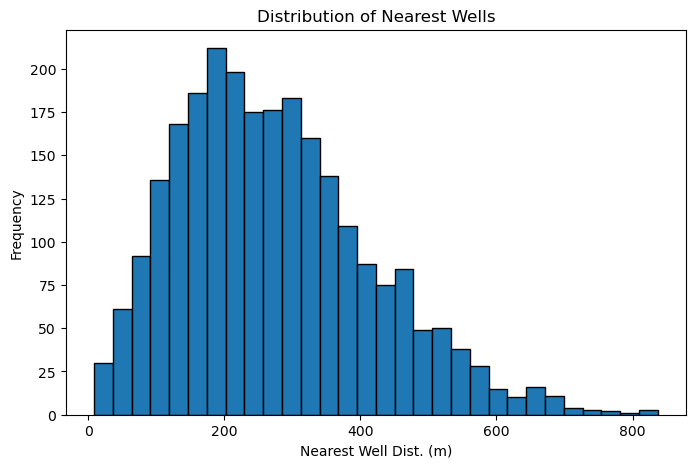

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(wells["Nearest_Well_Distance"], bins=30, edgecolor="black")
plt.title("Distribution of Nearest Wells")
plt.xlabel("Nearest Well Dist. (m)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
gdf_wells_spacing = gdf_wells.copy()
gdf_wells_spacing["Nearest_Well_Dist"] = wells["Nearest_Well_Distance"]

In [ ]:
gdf_wells_spacing.head()

,Well_ID,Well_Name,X_UTM_m,Y_UTM_m,CRS_EPSG,Field,Block,Quadrant,Trajectory,Status,...,Total_Depth_MD_m,Total_Depth_TVDSS_m,Deviation_Azimuth_deg,Max_Inclination_deg,Lateral_Length_m,Distance_to_Nearest_Fault_m,Nearest_Fault_ID,Reservoir_Quality_Index,geometry,Nearest_Well_Dist
0,KW-0001,Kimbala-0001,499487.37,782754.65,32632,Kimbala,B02-02,SW,Vertical,Producer,...,3226.2,3152.0,NaN,5.4,0.0,3252.6,F03,37.2,POINT (499487.37 782754.65),357.182259
1,KW-0002,Kimbala-0002,519217.08,777630.58,32632,Kimbala,B02-05,SE,Deviated,DryHole,...,3374.2,3374.2,221.4,36.9,429.6,190.2,F06,40.7,POINT (519217.08 777630.58),343.726017
2,KW-0003,Kimbala-0003,521265.78,789047.99,32632,Kimbala,B03-06,NE,Vertical,Appraisal,...,3251.2,3224.9,NaN,0.4,0.0,668.6,F06,42.6,POINT (521265.78 789047.99),373.279525
3,KW-0004,Kimbala-0004,523734.25,793852.73,32632,Kimbala,B04-06,NE,Horizontal,DryHole,...,4655.7,3051.6,108.4,84.5,2238.6,817.1,F06,39.2,POINT (523734.25 793852.73),314.098677
4,KW-0005,Kimbala-0005,510791.07,793959.06,32632,Kimbala,B04-04,NE,Vertical,Producer,...,2905.5,2905.5,NaN,2.5,0.0,717.7,F04,37.7,POINT (510791.07 793959.06),313.546683


In [ ]:
faults.head()

,Fault_ID,Throw_Class,geometry
0,F01,minor,"LINESTRING (491369.78 780493.527, 494675.835 7..."
1,F02,moderate,"LINESTRING (491522.493 779335.207, 492473.413 ..."
2,F03,moderate,"LINESTRING (496186.872 774389.972, 496292.017 ..."
3,F04,minor,"LINESTRING (504966.045 770041.155, 510531.319 ..."
4,F05,minor,"LINESTRING (511000.218 769404.813, 513332.153 ..."


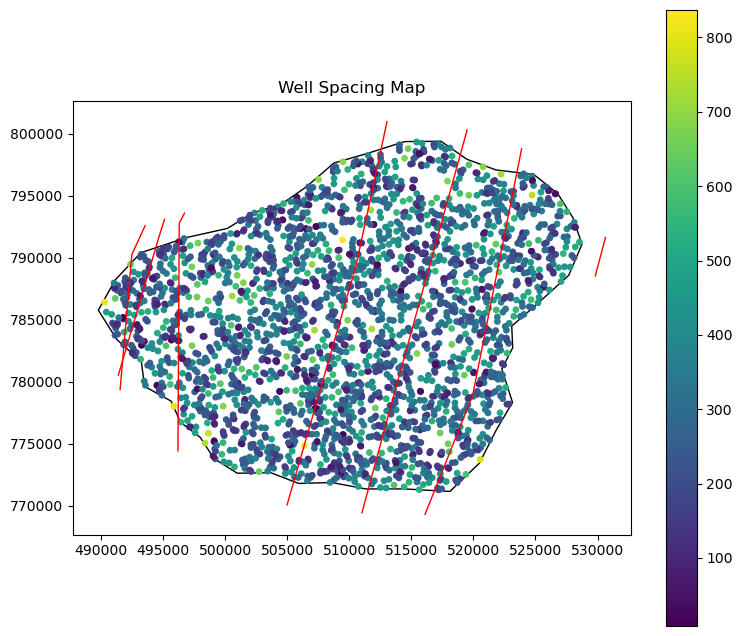

In [ ]:
fig, ax = plt.subplots(figsize=(9,8))
field.plot(ax=ax, facecolor="none", edgecolor="black")
faults.plot(ax=ax, color="red", lw=1)
gdf_wells_spacing.plot(ax=ax, column="Nearest_Well_Dist", cmap="viridis",
                       legend=True, markersize=15)

ax.set_title("Well Spacing Map")
plt.show()

In [ ]:
faults.head()

,Fault_ID,Throw_Class,geometry
0,F01,minor,"LINESTRING (491369.78 780493.527, 494675.835 7..."
1,F02,moderate,"LINESTRING (491522.493 779335.207, 492473.413 ..."
2,F03,moderate,"LINESTRING (496186.872 774389.972, 496292.017 ..."
3,F04,minor,"LINESTRING (504966.045 770041.155, 510531.319 ..."
4,F05,minor,"LINESTRING (511000.218 769404.813, 513332.153 ..."


In [ ]:
#Distance to Faults Analysis

faults_union = faults.union_all()
gdf_wells["Comp._Dist_to_Fault"] = gdf_wells.geometry.apply(lambda geom: geom.distance(faults_union))

gdf_wells.head()

,Well_ID,Well_Name,X_UTM_m,Y_UTM_m,CRS_EPSG,Field,Block,Quadrant,Trajectory,Status,...,Total_Depth_MD_m,Total_Depth_TVDSS_m,Deviation_Azimuth_deg,Max_Inclination_deg,Lateral_Length_m,Distance_to_Nearest_Fault_m,Nearest_Fault_ID,Reservoir_Quality_Index,geometry,Comp._Dist_to_Fault
0,KW-0001,Kimbala-0001,499487.37,782754.65,32632,Kimbala,B02-02,SW,Vertical,Producer,...,3226.2,3152.0,NaN,5.4,0.0,3252.6,F03,37.2,POINT (499487.37 782754.65),3252.646126
1,KW-0002,Kimbala-0002,519217.08,777630.58,32632,Kimbala,B02-05,SE,Deviated,DryHole,...,3374.2,3374.2,221.4,36.9,429.6,190.2,F06,40.7,POINT (519217.08 777630.58),190.248516
2,KW-0003,Kimbala-0003,521265.78,789047.99,32632,Kimbala,B03-06,NE,Vertical,Appraisal,...,3251.2,3224.9,NaN,0.4,0.0,668.6,F06,42.6,POINT (521265.78 789047.99),668.573039
3,KW-0004,Kimbala-0004,523734.25,793852.73,32632,Kimbala,B04-06,NE,Horizontal,DryHole,...,4655.7,3051.6,108.4,84.5,2238.6,817.1,F06,39.2,POINT (523734.25 793852.73),817.094280
4,KW-0005,Kimbala-0005,510791.07,793959.06,32632,Kimbala,B04-04,NE,Vertical,Producer,...,2905.5,2905.5,NaN,2.5,0.0,717.7,F04,37.7,POINT (510791.07 793959.06),717.728586


In [ ]:
gdf_wells.columns

Index(['Well_ID', 'Well_Name', 'X_UTM_m', 'Y_UTM_m', 'CRS_EPSG', 'Field',
       'Block', 'Quadrant', 'Trajectory', 'Status', 'Completion_Type',
       'Spud_Date', 'Completion_Date', 'KB_Elevation_m', 'Water_Depth_m',
       'Top_Reservoir_TVDSS_m', 'Gross_Thickness_m', 'Net_to_Gross_frac',
       'NetPay_m', 'Porosity_frac', 'Permeability_mD', 'Water_Saturation_frac',
       'Oil_Saturation_frac', 'Gas_Saturation_frac', 'Total_Depth_MD_m',
       'Total_Depth_TVDSS_m', 'Deviation_Azimuth_deg', 'Max_Inclination_deg',
       'Lateral_Length_m', 'Distance_to_Nearest_Fault_m', 'Nearest_Fault_ID',
       'Reservoir_Quality_Index', 'geometry', 'Comp._Dist_to_Fault'],
      dtype='object')

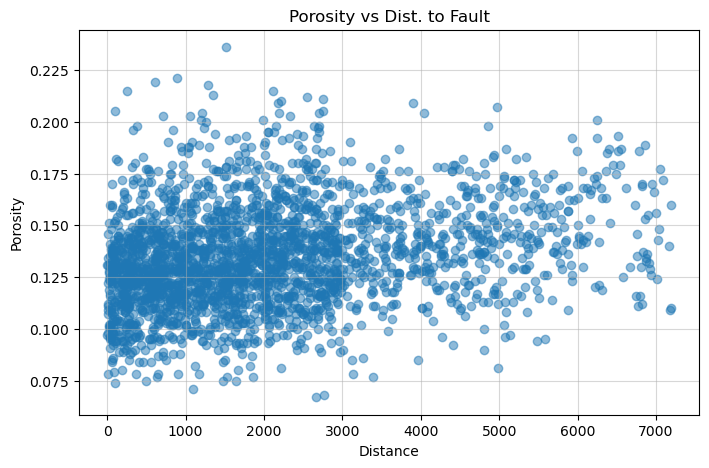

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(gdf_wells["Comp._Dist_to_Fault"], gdf_wells["Porosity_frac"], alpha=0.5)
plt.title("Porosity vs Dist. to Fault")
plt.xlabel("Distance")
plt.ylabel("Porosity")
plt.grid(alpha=0.5)

plt.show()


In [ ]:
gdf_wells[["Comp._Dist_to_Fault", "Porosity_frac"]].corr()

,Comp._Dist_to_Fault,Porosity_frac
Comp._Dist_to_Fault,1.00000,0.26059
Porosity_frac,0.26059,1.00000
